# Libraries

In [ ]:
options(future.globals.maxSize = 100000000 * 1024^2)
# set random seed for reproducibility
set.seed(12345)

# === Single-Cell Analysis Libraries ===
library(Seurat)               # Comprehensive toolkit for single-cell RNA-seq analysis
library(SingleCellExperiment) # Framework for storing and manipulating single-cell data
library(scCustomize)          # Customizations and enhancements for Seurat workflows
library(patchwork)
library(RColorBrewer)

save_plot <- FALSE

In [5]:
WGCNA_dir = '7.WGCNA/'
input_rds <-  paste0(WGCNA_dir,'2024_03_28_Myeloid_Metacells_Subclass_ADAM.rds.ztsd')


In [8]:

Metacells <- readCRDS(input_rds)
Metacells$TwoClusters <-  as.vector(Metacells$Clusters)
Metacells$TwoClusters[Metacells$Clusters %in% c("MTC_1","MTC_2","MTC_3")] <- "MTC_123"
Metacells$TwoClusters[Metacells$Clusters %in% c("MTC_4","MTC_5","MTC_6")]<- "MTC_456"


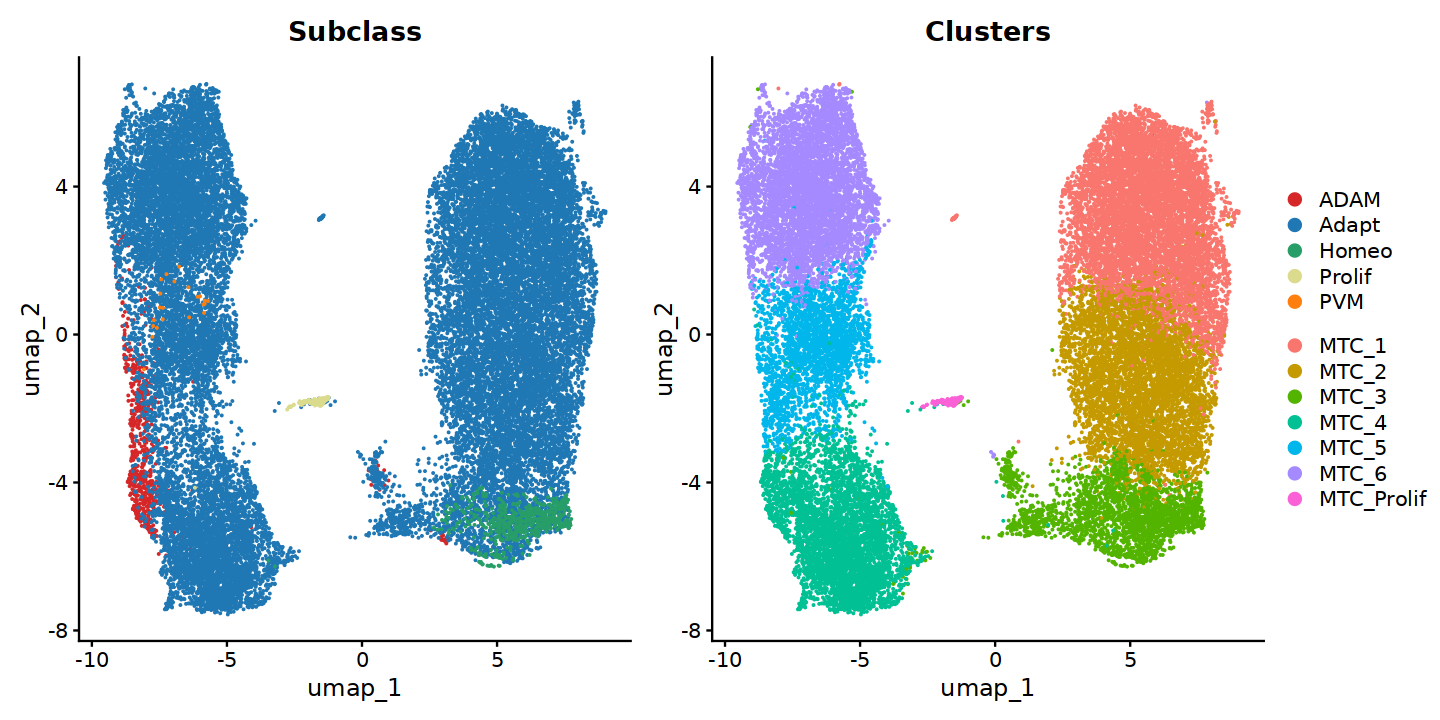

In [12]:
options(repr.plot.width=12, repr.plot.height=6)
p1 <- DimPlot(Metacells,group.by = 'Subclass',cols=Project_Colors)
p2 <- DimPlot(Metacells,group.by = 'Clusters')

if(save_plot){
    pdf('Figure2_B.pdf',width = 12,height=6)
    p1+p2+plot_layout(guides = 'collect')
    dev.off()    
}else{
   p1+p2+plot_layout(guides = 'collect')
}
    

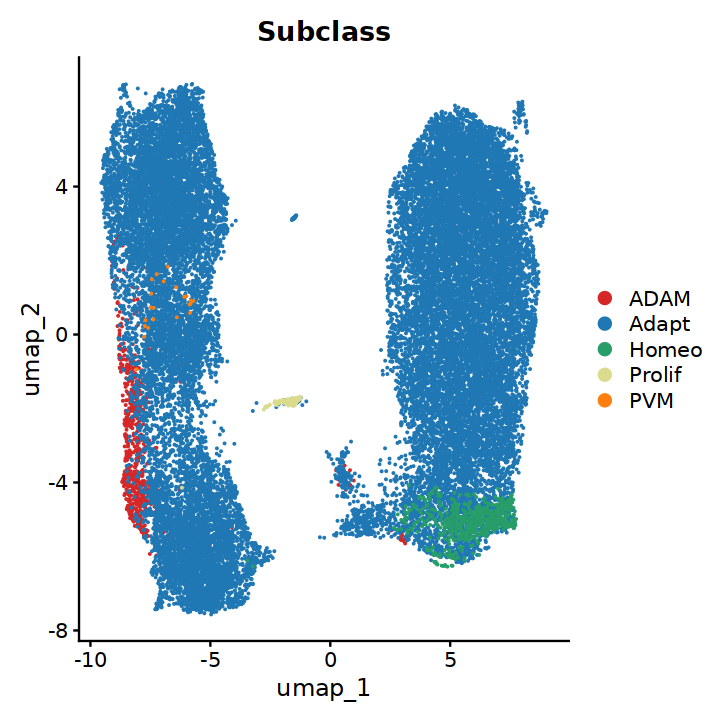

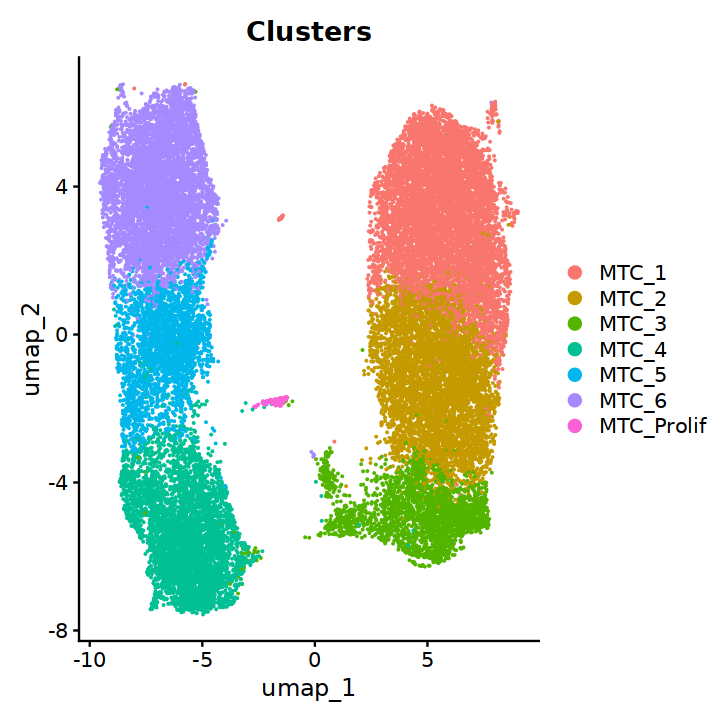

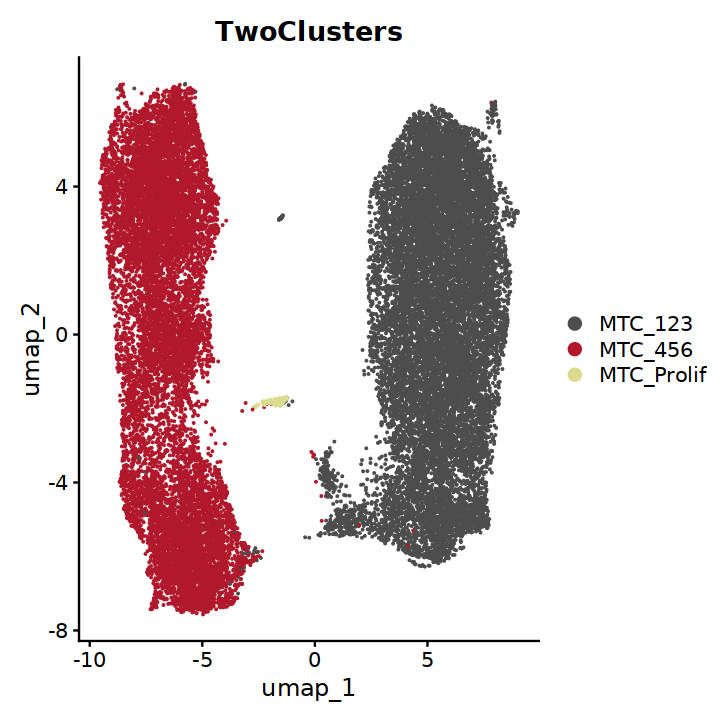

In [16]:
options(repr.plot.width=6, repr.plot.height=6)
colors_rb <- rev(brewer.pal(n = 6, name = 'RdGy'))
# pdf('/sc/arion/projects/CommonMind/kyriad02/ICH_Stroke/Figures/Figure2_B1.pdf',width = 6,height=6)
DimPlot(Metacells,group.by = 'Subclass',cols=Project_Colors)
# dev.off()

# pdf('/sc/arion/projects/CommonMind/kyriad02/ICH_Stroke/Figures/Figure2_B2.pdf',width = 6,height=6)
DimPlot(Metacells,group.by = 'Clusters')
# dev.off()

# pdf('/sc/arion/projects/CommonMind/kyriad02/ICH_Stroke/Figures/Figure2_B3.pdf',width = 6,height=6)
DimPlot(Metacells,group.by = 'TwoClusters',cols=c(colors_rb[c(1,6)],'#dbdb8d'))
# dev.off()

In [17]:
sessionInfo()

R version 4.3.0 (2023-04-21)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Rocky Linux 9.4 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /sc/arion/work/kyriad02/miniconda3/envs/dreamlet430/lib/libopenblasp-r0.3.23.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] RColorBrewer_1.1-3          patchwork_1.2.0            
 [3] scCustomize_1.1.1           SingleCellExperiment_1.22.0
 [5] SummarizedExperiment_1.30.2 Biobase_2.60.0             